Imports

In [19]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.signal import periodogram
import warnings
warnings.filterwarnings("ignore")

Cargar rutas

In [20]:
DATA_PATH    = Path("../../data/features/hotel_ttoo")
METRICS_PATH = Path("../../models/metrics")
METRICS_PATH.mkdir(parents=True, exist_ok=True)

Cargar dataset

In [21]:
files = {
    "HOTEL_1": DATA_PATH / "HOTEL_1.parquet",
    "HOTEL_2": DATA_PATH / "HOTEL_2.parquet",
    "HOTEL_3": DATA_PATH / "HOTEL_3.parquet",
}
data = {}
for hotel, path in files.items():
    df = pd.read_parquet(path)
    df["fecha"] = pd.to_datetime(df["fecha"], unit="ms")
    df = df.sort_values("fecha").set_index("fecha").asfreq("D")
    data[hotel] = df

print("Datasets cargados correctamente")

Datasets cargados correctamente


Función ADF

In [22]:
def adf_test(series, name="Serie"):
    result = adfuller(series.dropna())
    print(f"ADF Test - {name}")
    print("ADF Statistic:", round(result[0], 4))
    print("p-value:",       round(result[1], 4))

Split temporal

In [23]:
CUTOFF = pd.Timestamp("2025-01-01")

def train_test_split_cutoff(ts, cutoff=CUTOFF):
    return ts[ts.index < cutoff], ts[ts.index >= cutoff]

Búsqueda automática de SARIMA

In [24]:
def find_best_sarima(series, hotel):
    series = series.dropna()
    model_auto = auto_arima(
        series,
        seasonal=True,
        m=7,
        trace=False,
        error_action="ignore",
        suppress_warnings=True,
        stepwise=True
    )
    print(f"\nMejor SARIMA para {hotel}:")
    print(f"order = {model_auto.order}")
    print(f"seasonal_order = {model_auto.seasonal_order}")
    return model_auto.order, model_auto.seasonal_order

Función SARIMA

In [25]:
def compute_metrics_safe(y_true_s, y_pred_s, eps=1e-8, label=""):
    y_pred_s = y_pred_s.reindex(y_true_s.index)
    y_true   = y_true_s.to_numpy(dtype=float)
    y_pred   = y_pred_s.to_numpy(dtype=float)
    mask     = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if mask.sum() == 0:
        print(f"\n[DIAGNÓSTICO {label}] No hay pares válidos (todo NaN tras alinear).")
        print("Resumen y_true:", y_true_s.describe())
        print("Resumen y_pred reindex:", y_pred_s.describe())
        print("¿Índices iguales?:", y_true_s.index.equals(y_pred_s.index))
        print("Primeras fechas test:", y_true_s.index[:5])
        print("Primeras fechas pred:", y_pred_s.index[:5])
        raise ValueError("Máscara vacía: revisa asfreq('D'), índices y longitud del forecast.")
    y_true = y_true[mask]; y_pred = y_pred[mask]
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    mape  = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0
    return float(mae), float(rmse), float(mape)

In [26]:
def run_sarima(series, hotel):
    series = series.dropna()
    train, test = train_test_split_cutoff(series)
    if len(train) == 0 or len(test) == 0:
        raise ValueError(f"{hotel}: train/test vacío con cutoff {CUTOFF}")

    order, seasonal_order = find_best_sarima(train, hotel)
    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)
    fc  = res.get_forecast(steps=len(test))
    pred = fc.predicted_mean
    ci   = fc.conf_int(alpha=0.05)

    if len(pred) == len(test):
        pred.index = test.index
    else:
        min_len = min(len(pred), len(test))
        pred = pd.Series(pred.values[:min_len], index=test.index[:min_len])
        test = test.iloc[:min_len]
        ci   = ci.iloc[:min_len]

    pred = pred.reindex(test.index)
    ci   = ci.reindex(test.index)

    mae, rmse, mape = compute_metrics_safe(test, pred, label=f"SARIMA {hotel}")

    plt.figure(figsize=(14, 6))
    plt.plot(train.index, train, label="Train",           color="C0")
    plt.plot(test.index,  test,  label="Test",            color="C1")
    plt.plot(test.index,  pred,  label="SARIMA Forecast", color="C2")
    plt.fill_between(test.index, ci.iloc[:, 0], ci.iloc[:, 1],
                     color="C2", alpha=0.15, label="IC 95%")
    plt.title(f"SARIMA Forecast – {hotel}")
    plt.xlabel("Fecha"); plt.ylabel("Ocupación")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return res, (mae, rmse, mape), (pred, ci, train, test), (order, seasonal_order)

Loop por hotel

ADF Test - HOTEL_1
ADF Statistic: -4.7096
p-value: 0.0001

Mejor SARIMA para HOTEL_1:
order = (1, 1, 1)
seasonal_order = (2, 0, 1, 7)


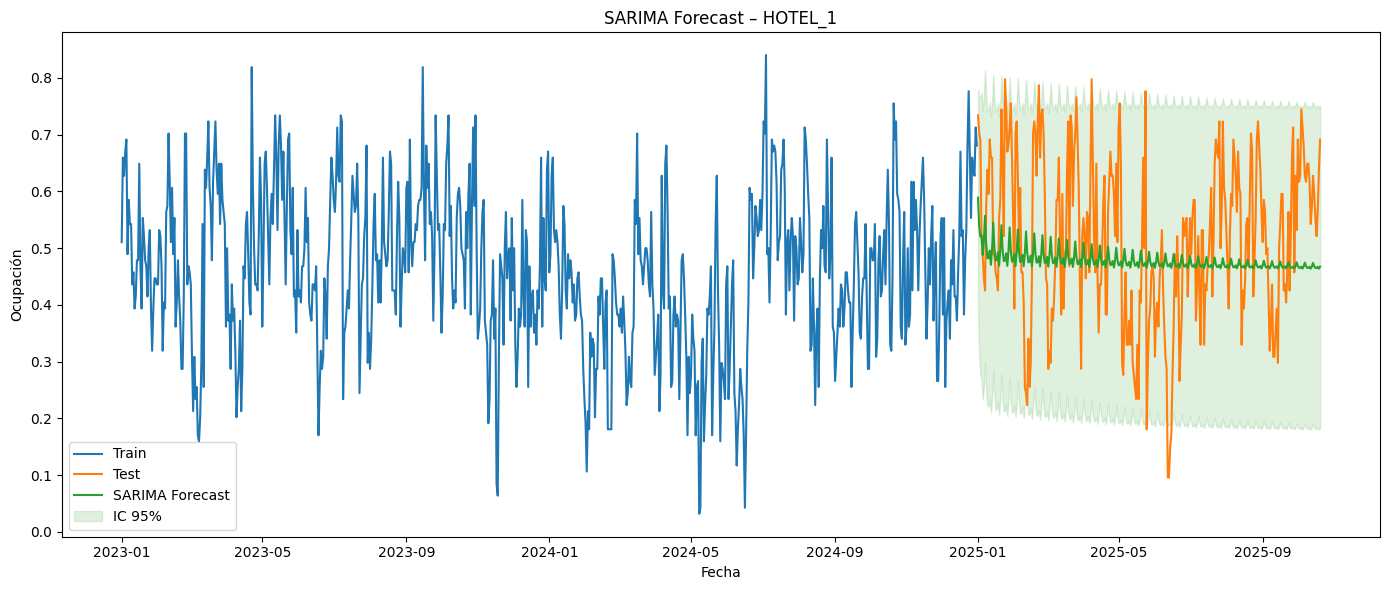

ADF Test - HOTEL_2
ADF Statistic: -2.346
p-value: 0.1576

Mejor SARIMA para HOTEL_2:
order = (2, 1, 3)
seasonal_order = (2, 0, 1, 7)


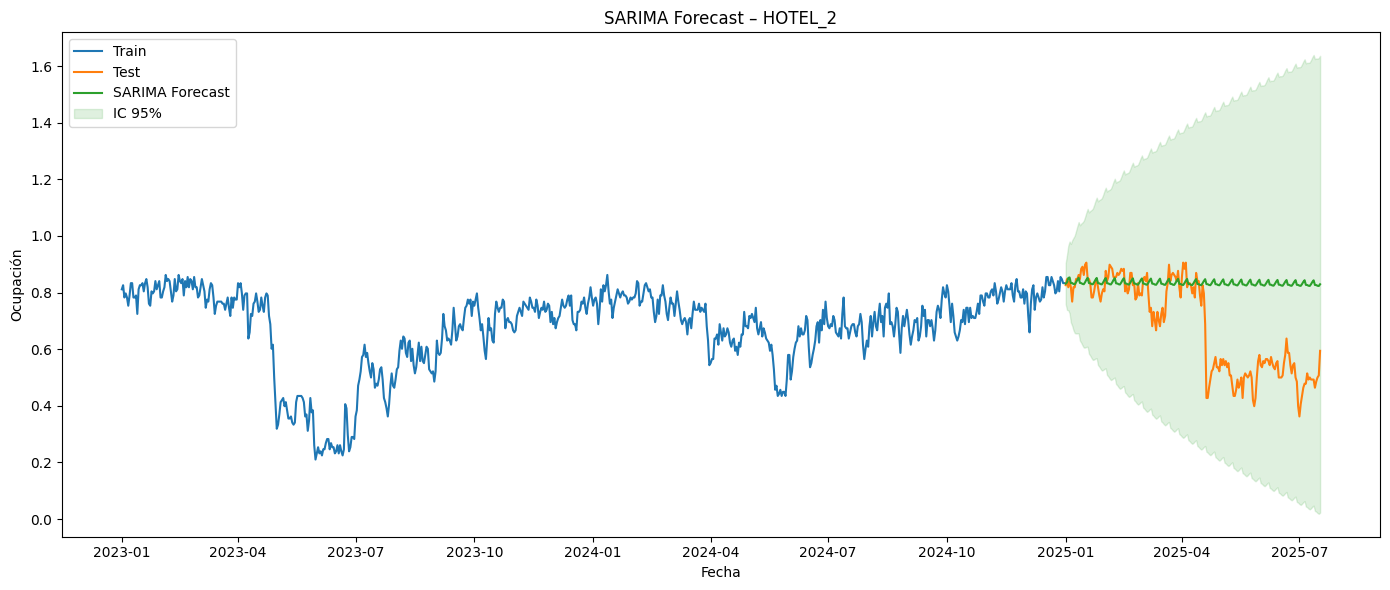

ADF Test - HOTEL_3
ADF Statistic: -2.7234
p-value: 0.0701

Mejor SARIMA para HOTEL_3:
order = (1, 1, 3)
seasonal_order = (1, 0, 0, 7)


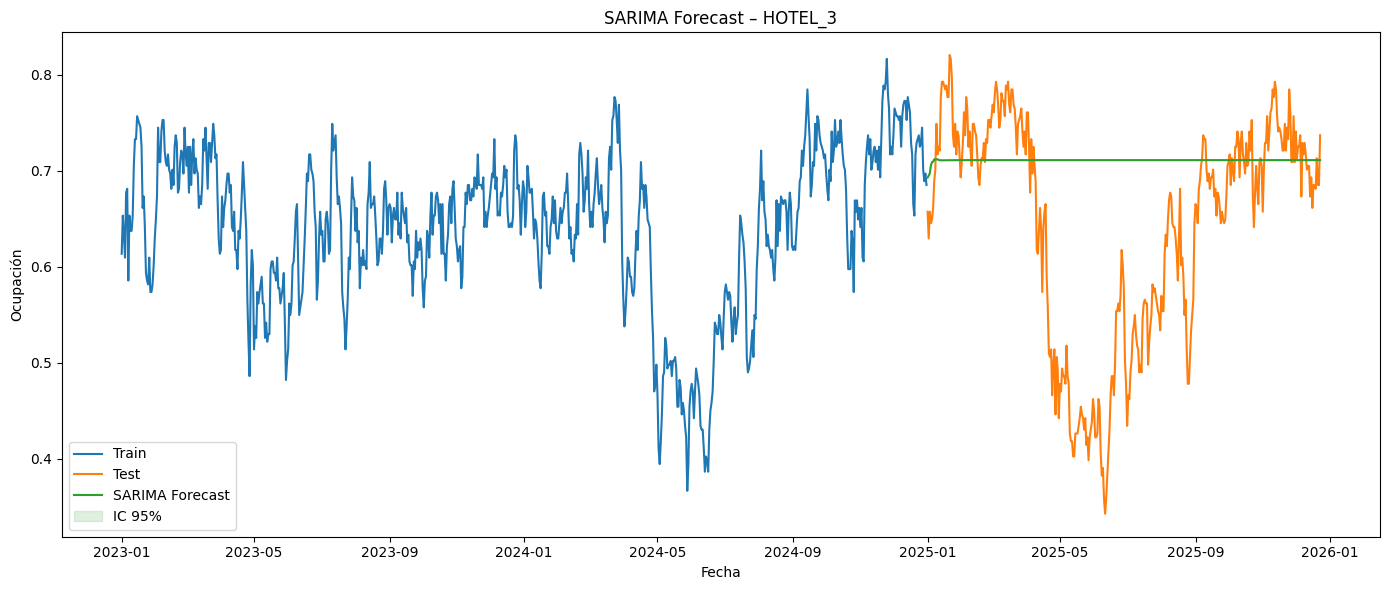

,hotel,modelo,order,seasonal_order,MAE,RMSE,MAPE
0,HOTEL_1,SARIMA,"(1, 1, 1)","(2, 0, 1, 7)",0.122953,0.147184,28.319673
1,HOTEL_2,SARIMA,"(2, 1, 3)","(2, 0, 1, 7)",0.167298,0.221871,32.001329
2,HOTEL_3,SARIMA,"(1, 1, 3)","(1, 0, 0, 7)",0.097969,0.136813,19.176906


In [27]:
results = []
models  = {}
for hotel, df in data.items():
    ts = df["ocup_total"].asfreq("D")
    adf_test(ts, hotel)
    res, (mae, rmse, mape), (pred, ci, train, test), (order, seasonal_order) = run_sarima(ts, hotel)
    results.append({
        "hotel":          hotel,
        "modelo":         "SARIMA",
        "order":          str(order),
        "seasonal_order": str(seasonal_order),
        "MAE":            mae,
        "RMSE":           rmse,
        "MAPE":           mape
    })
    models[hotel] = {
        "res": res,
        "order": order, "seasonal_order": seasonal_order,
        "train": train, "test": test, "pred": pred, "ci": ci
    }

results_df = pd.DataFrame(results).sort_values("hotel")
results_df

Resultados

In [28]:
results_df.to_csv(METRICS_PATH / "sarima_results.csv", index=False)
print("Resultados guardados")

Resultados guardados


Predicciones

In [29]:
PRED_PATH = METRICS_PATH.parent / "predictions"
PRED_PATH.mkdir(parents=True, exist_ok=True)

pred_rows = []
for hotel, obj in models.items():
    pred = obj["pred"].reindex(obj["test"].index)
    pred_rows.append(pd.DataFrame({
        "fecha":  obj["test"].index,
        "hotel":  hotel,
        "modelo": "SARIMA",
        "y_real": obj["test"].values,
        "y_pred": pred.values
    }))

df_pred_sarima = pd.concat(pred_rows, ignore_index=True)
out_file = PRED_PATH / "sarima_predictions.parquet"
df_pred_sarima.to_parquet(out_file, index=False)
print("✅ Predicciones SARIMA guardadas en:", out_file)
df_pred_sarima.head()

✅ Predicciones SARIMA guardadas en: ..\..\models\predictions\sarima_predictions.parquet


,fecha,hotel,modelo,y_real,y_pred
0,2025-01-01,HOTEL_1,SARIMA,0.734043,0.588947
1,2025-01-02,HOTEL_1,SARIMA,0.702128,0.537781
2,2025-01-03,HOTEL_1,SARIMA,0.691489,0.520434
3,2025-01-04,HOTEL_1,SARIMA,0.521277,0.522337
4,2025-01-05,HOTEL_1,SARIMA,0.489362,0.487872


ACF/PACF de residuos (¿quedó estacionalidad?)

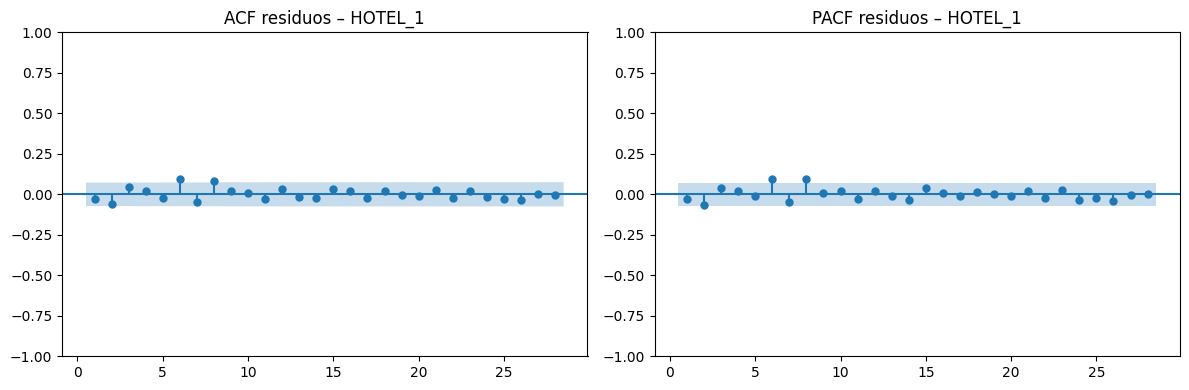

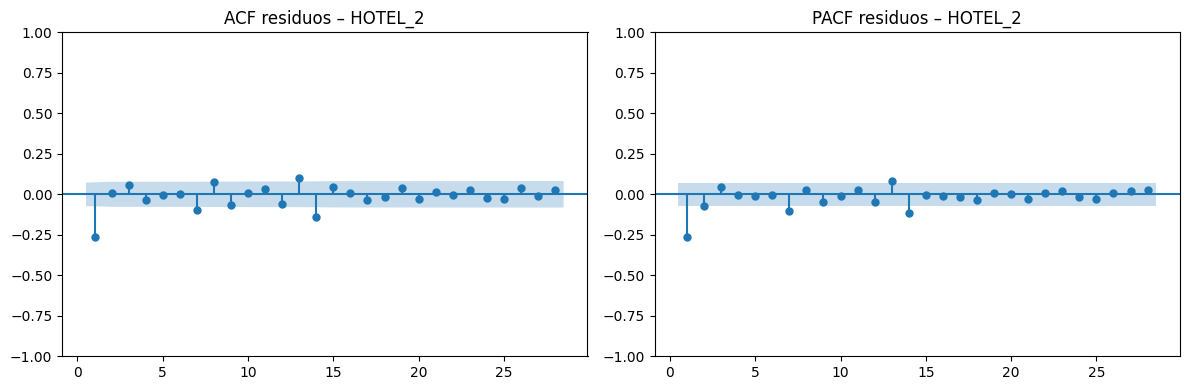

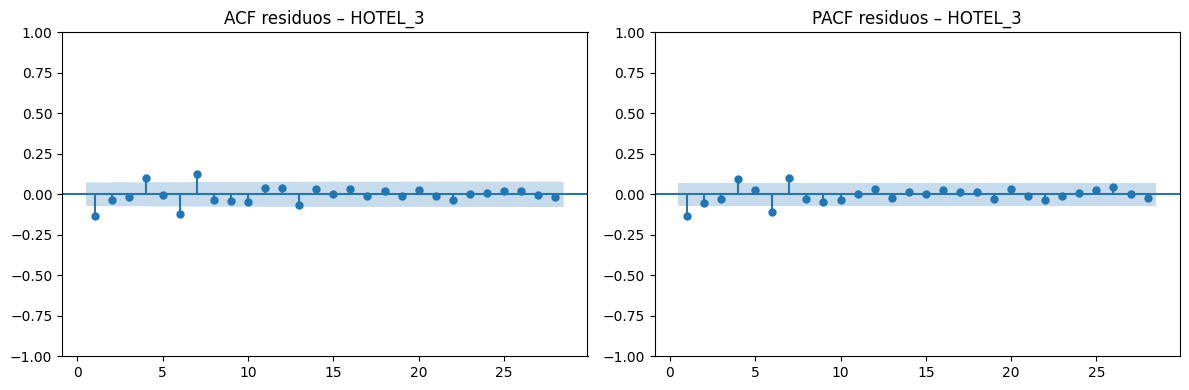

In [30]:
for hotel, obj in models.items():
    resid = obj["res"].resid.dropna()
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf( resid, lags=28, zero=False, ax=ax[0])
    plot_pacf(resid, lags=28, zero=False, ax=ax[1])
    ax[0].set_title(f"ACF residuos – {hotel}")
    ax[1].set_title(f"PACF residuos – {hotel}")
    plt.tight_layout()
    plt.show()

Periodograma simple (pico en 7 días)


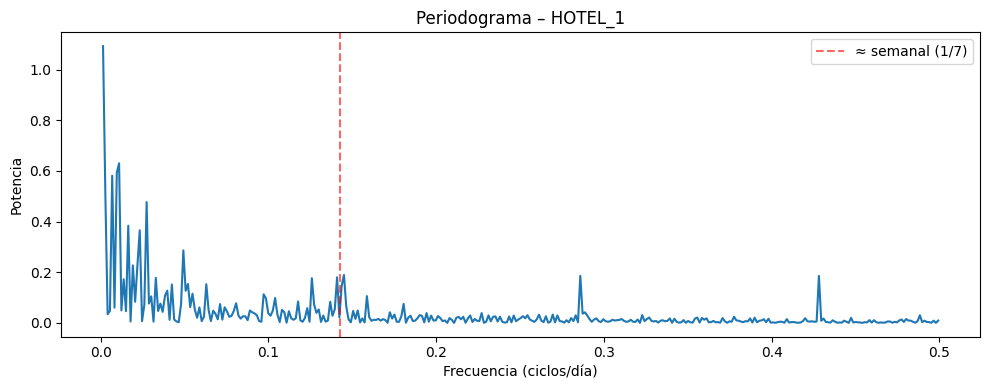

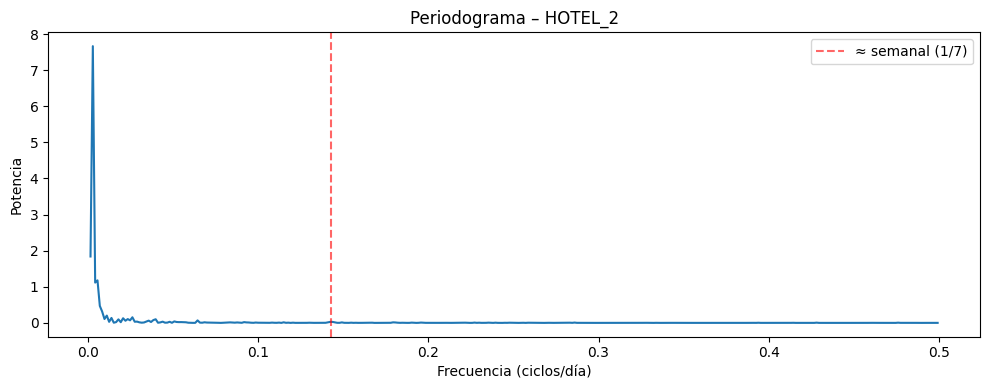

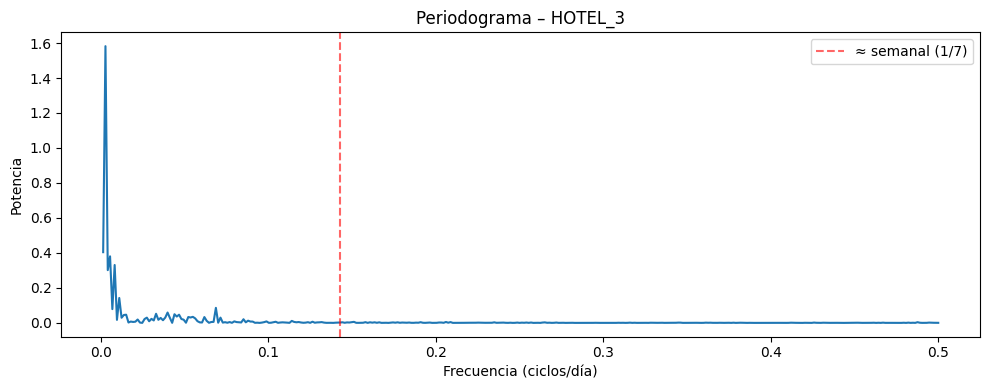

In [31]:
for hotel, obj in models.items():
    y = obj["train"].ffill().values
    freqs, power = periodogram(y, fs=1.0)
    plt.figure(figsize=(10, 4))
    plt.plot(freqs[1:], power[1:])
    plt.title(f"Periodograma – {hotel}")
    plt.xlabel("Frecuencia (ciclos/día)")
    plt.ylabel("Potencia")
    plt.axvline(1/7, color='r', linestyle='--', alpha=0.6, label='≈ semanal (1/7)')
    plt.legend()
    plt.tight_layout()
    plt.show()

Importancia / influencia en SARIMA

In [32]:
summary_rows = [
    {"hotel": h, "order_(p,d,q)": obj["order"], "seasonal_(P,D,Q,s)": obj["seasonal_order"]}
    for h, obj in models.items()
]
sarima_orders_df = pd.DataFrame(summary_rows).sort_values("hotel")
display(sarima_orders_df)

,hotel,"order_(p,d,q)","seasonal_(P,D,Q,s)"
0,HOTEL_1,"(1, 1, 1)","(2, 0, 1, 7)"
1,HOTEL_2,"(2, 1, 3)","(2, 0, 1, 7)"
2,HOTEL_3,"(1, 1, 3)","(1, 0, 0, 7)"


Ganancia de SARIMA vs ARIMA

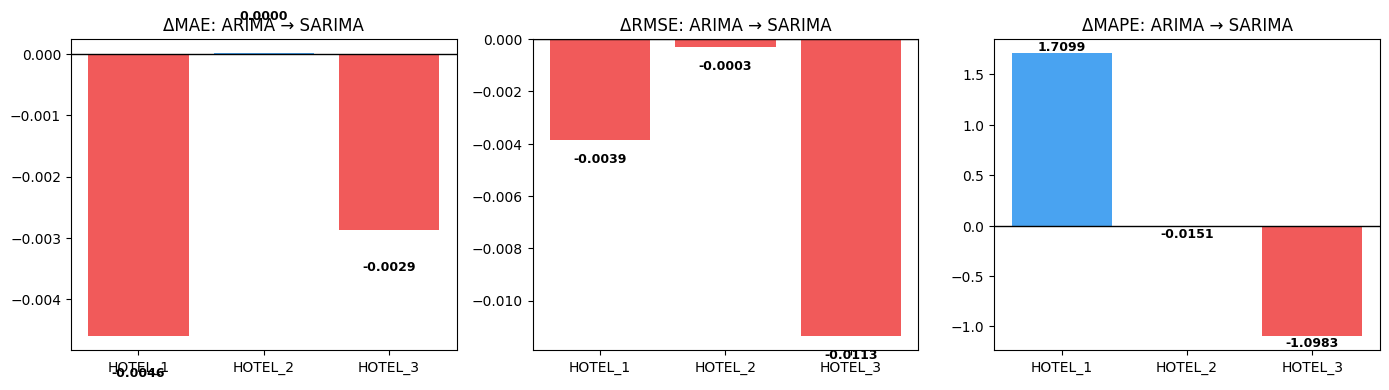

In [33]:
arima  = pd.read_csv("../../models/metrics/arima_results.csv")[["hotel","MAE","RMSE","MAPE"]]
sarima = pd.read_csv("../../models/metrics/sarima_results.csv")[["hotel","MAE","RMSE","MAPE"]]
arima  = arima.rename(columns={"MAE":"MAE_ARIMA","RMSE":"RMSE_ARIMA","MAPE":"MAPE_ARIMA"})
sarima = sarima.rename(columns={"MAE":"MAE_SARIMA","RMSE":"RMSE_SARIMA","MAPE":"MAPE_SARIMA"})
comp   = sarima.merge(arima, on="hotel", how="left").sort_values("hotel").reset_index(drop=True)

comp["ΔMAE"]  = comp["MAE_ARIMA"]  - comp["MAE_SARIMA"]
comp["ΔRMSE"] = comp["RMSE_ARIMA"] - comp["RMSE_SARIMA"]
comp["ΔMAPE"] = comp["MAPE_ARIMA"] - comp["MAPE_SARIMA"]

hoteles = comp["hotel"].tolist()

def colorize(vals):
    return ["#49a3f1" if v > 0 else "#f15a5a" for v in vals]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, nombre in zip(axes, ["ΔMAE", "ΔRMSE", "ΔMAPE"]):
    vals    = comp[nombre].values
    colores = colorize(vals)
    bars    = ax.bar(hoteles, vals, color=colores)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f"{nombre}: ARIMA → SARIMA")
    for bar, v in zip(bars, vals):
        if np.isnan(v):
            continue
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()
        offset = 0.0005 if v >= 0 else -0.0005
        ax.text(x, y + offset, f"{v:.4f}",
                ha='center', va='bottom' if v >= 0 else 'top',
                fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# Conclusiones — Modelo SARIMA (con estacionalidad semanal, s=7)

## Objetivo

Evaluar si añadir estacionalidad semanal (s=7) a un ARIMA (es decir, SARIMA) mejora
la predicción de la ocupación diaria por hotel y entender qué componente temporal
"pesa" más (inercia diaria vs. patrón semanal).

---

## Diagnóstico previo (ADF en entrenamiento)

El test ADF se aplica sobre el **conjunto de entrenamiento**, definido como fechas
anteriores a 2025‑01‑01:

- **Hotel 1:** ADF < 0, *p* < 0.01 → serie estacionaria.
- **Hotel 2:** *p* > 0.05 → no estacionaria (requiere diferenciación).
- **Hotel 3:** *p* > 0.05 → no estacionaria (requiere diferenciación).

En **Hotel 2 y Hotel 3** está justificado diferenciar (*d = 1*). En **Hotel 1**
la serie es más estable, aunque el uso de *d = 1* no invalida el entrenamiento
y permite homogeneizar el enfoque.

---

## Órdenes seleccionados por hotel (auto_arima con s=7)

Los parámetros se seleccionan automáticamente sobre el conjunto de entrenamiento
(fechas < 2025‑01‑01):

| Hotel   | order (p,d,q) | seasonal (P,D,Q,s) |
|--------:|---------------|--------------------|
| Hotel 1 | (1, 1, 1)     | (2, 0, 1, 7)       |
| Hotel 2 | (2, 1, 3)     | (2, 0, 1, 7)       |
| Hotel 3 | (1, 1, 3)     | (1, 0, 0, 7)       |

Hotel 1 y Hotel 3 incorporan componente estacional (P>0 y/o Q>0), lo que indica
que el patrón semanal sí aporta información. En Hotel 2, aunque se introduce
estacionalidad, el modelo sigue mostrando un comportamiento dominado por la
inercia diaria y cambios de nivel.

---

## Resultados en test (cutoff temporal fijo)

La evaluación se realiza con un criterio temporal homogéneo:

- **Entrenamiento:** fechas < 2025‑01‑01
- **Test:** fechas ≥ 2025‑01‑01 hasta el último histórico disponible

Resultados SARIMA en test:

| Hotel   |    MAE |   RMSE | MAPE (%) |
|--------:|-------:|-------:|---------:|
| Hotel 1 | 0.1230 | 0.1472 |    28.32 |
| Hotel 2 | 0.1673 | 0.2219 |    32.00 |
| Hotel 3 | 0.0980 | 0.1368 |    19.18 |

Comparando **ARIMA → SARIMA**:

- **Hotel 1:** ligera mejora en MAE y RMSE, pero empeora el MAPE.
- **Hotel 2:** diferencias prácticamente nulas respecto a ARIMA.
- **Hotel 3:** mejora clara y consistente en MAE, RMSE y MAPE.

La incorporación de estacionalidad semanal **solo aporta ganancia apreciable en Hotel 3**.

---

## Comportamiento visual (forecast + IC 95%)

- **Hotel 1:** el forecast se estabiliza alrededor de un nivel medio, con bandas
  amplias; no reproduce picos ni caídas bruscas.
- **Hotel 2:** el modelo permanece relativamente plano y la incertidumbre crece;
  la estacionalidad semanal no mejora el seguimiento de descensos en test.
- **Hotel 3:** se observa una ligera mejora respecto a ARIMA, con una curva más
  coherente, aunque todavía insuficiente para capturar cambios recientes con precisión.

---

## Residuos (ACF/PACF) y periodograma

- **ACF/PACF de residuos:** no aparecen picos semanales dominantes tras el ajuste,
  lo que indica que la parte estacional modelada no deja estructura clara remanente;
  aun así, el error sigue siendo elevado por variabilidad no explicada.
- **Periodograma:** el componente semanal (~1/7) no es dominante en Hotel 2,
  mientras que sí aparece con mayor claridad en Hotel 1 y, especialmente, en
  Hotel 3, coherente con los órdenes seleccionados.

---

## Interpretación ("influencia temporal" en SARIMA)

- **Inercia diaria (p, q):** presente en los tres hoteles; el pasado inmediato
  influye, pero no es suficiente.
- **Estacionalidad semanal (P, Q con s=7):**
  - Aporta información en **Hotel 1 y Hotel 3**, aunque sin transformar de forma
    decisiva el poder predictivo.
  - En **Hotel 2**, la estacionalidad semanal es débil o inestable; el hotel
    parece guiado por cambios de nivel y choques no repetitivos.
- **Diferenciación (d = 1):** necesaria en Hotel 2 y Hotel 3, coherente con el
  diagnóstico ADF.

---

## Conclusión

- **SARIMA no supera de forma consistente a los baselines (Naive/MA7)** y solo
  mejora marginalmente a ARIMA.
- **Hotel 3** es el único caso donde la estacionalidad semanal aporta una mejora
  clara y sostenida.
- **Hotel 1 y Hotel 2** continúan mostrando suavizado excesivo y mala captura
  de picos de ocupación.

En conjunto, los resultados confirman que la ocupación hotelera **no depende
únicamente de su estructura temporal diaria o semanal**. La adopción de un
**cutoff temporal fijo** refuerza esta conclusión al eliminar sesgos de
comparación. La información verdaderamente predictiva parece residir en
**variables exógenas del negocio** (actividad por touroperador, calendario
operativo, dinámica de canales), lo que justifica avanzar hacia **SARIMAX y
modelos de Machine Learning** capaces de capturar no linealidades e interacciones
reales de la demanda.